# Pitch Modulation

| Function | Description |
| --- | --- |
| `vibrato` | Pitch modulation via sinusoidally varying fractional delay. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.modulator import vibrato

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Vibrato: pitch modulation via variable fractional delay.

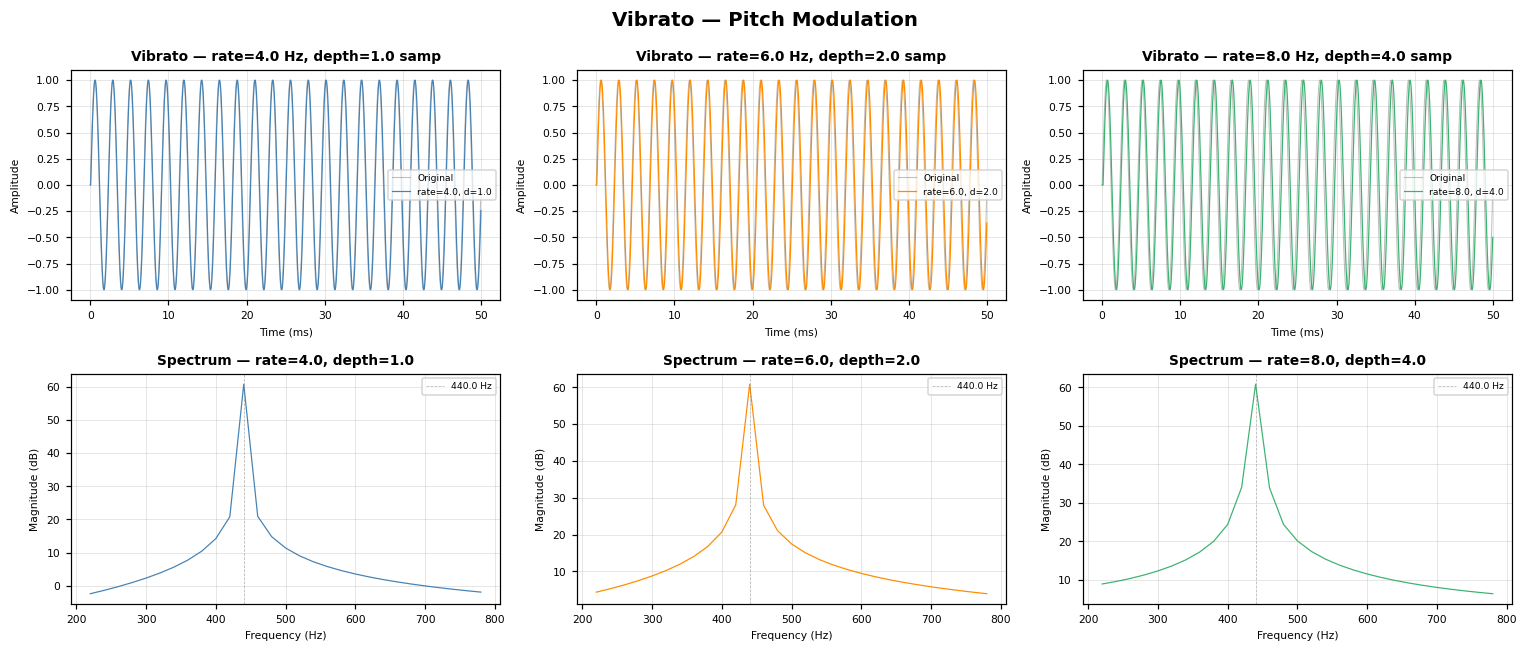

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 0.05

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000

RATES = [4.0, 6.0, 8.0]
DEPTHS = [1.0, 2.0, 4.0]
COLORS = ["steelblue", "darkorange", "mediumseagreen"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for col, (rate, depth, color) in enumerate(zip(RATES, DEPTHS, COLORS)):
    vib = vibrato(sig, rate=rate, depth_samples=depth, fs=FS)
    # Trim to same length (vibrato may pad internally)
    n = min(len(sig), len(vib))
    axes[0, col].plot(t_ms[:n], sig[:n], linewidth=0.7, color="gray", alpha=0.5, label="Original")
    axes[0, col].plot(t_ms[:n], vib[:n], linewidth=0.8, color=color, label=f"rate={rate}, d={depth}")
    axes[0, col].set_title(f"Vibrato — rate={rate} Hz, depth={depth} samp", fontsize=9, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].legend(fontsize=6)
    axes[0, col].tick_params(labelsize=7)
    axes[0, col].grid(True, linewidth=0.4, alpha=0.5)

# Spectrum for one case
for col, (rate, depth, color) in enumerate(zip(RATES, DEPTHS, COLORS)):
    vib = vibrato(sig, rate=rate, depth_samples=depth, fs=FS)
    n = min(len(sig), len(vib))
    freqs = np.fft.rfftfreq(n, d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(vib[:n])) + 1e-12)
    mask = (freqs > 200) & (freqs < 800)
    axes[1, col].plot(freqs[mask], db[mask], linewidth=0.8, color=color)
    axes[1, col].axvline(FREQ, color="gray", linewidth=0.5, linestyle="--", alpha=0.6, label=f"{FREQ} Hz")
    axes[1, col].set_title(f"Spectrum — rate={rate}, depth={depth}", fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Frequency (Hz)", fontsize=7)
    axes[1, col].set_ylabel("Magnitude (dB)", fontsize=7)
    axes[1, col].legend(fontsize=6)
    axes[1, col].tick_params(labelsize=7)
    axes[1, col].grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Vibrato — Pitch Modulation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()